In [3]:
!pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 5.9 MB/s eta 0:00:00


## **Pasos iniciales**

### Librerias

In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tqdm.notebook import tqdm
import math

from nba_api.stats.endpoints import PlayerGameLogs, TeamGameLogs, playercareerstats, CommonAllPlayers, CommonTeamYears
from nba_api.stats.library.parameters import SeasonAll

### Testing API

In [ ]:
from nba_api.stats.endpoints import playercareerstats

# Nikola Jokic
career = playercareerstats.PlayerCareerStats(player_id="203999")

# pandas dataframe
df_career = career.get_data_frames()[0]

In [ ]:
df_career.columns

Index(['PLAYER_ID', 'SEASON_ID', 'LEAGUE_ID', 'TEAM_ID', 'TEAM_ABBREVIATION',
       'PLAYER_AGE', 'GP', 'GS', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A',
       'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL',
       'BLK', 'TOV', 'PF', 'PTS'],
      dtype='object')

In [ ]:
df_career

,PLAYER_ID,SEASON_ID,LEAGUE_ID,TEAM_ID,TEAM_ABBREVIATION,PLAYER_AGE,GP,GS,MIN,FGM,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS
0,203999,2015-16,00,1610612743,DEN,21.0,80,55,1733,307,...,0.811,181,379,560,189,79,50,104,208,796
1,203999,2016-17,00,1610612743,DEN,22.0,73,59,2038,494,...,0.825,212,506,718,359,61,55,171,214,1221
2,203999,2017-18,00,1610612743,DEN,23.0,75,73,2443,504,...,0.850,195,608,803,458,90,61,210,212,1385
3,203999,2018-19,00,1610612743,DEN,24.0,80,80,2504,616,...,0.821,228,637,865,580,108,55,248,228,1604
4,203999,2019-20,00,1610612743,DEN,25.0,73,73,2335,565,...,0.817,166,545,711,512,85,44,226,222,1456
5,203999,2020-21,00,1610612743,DEN,26.0,72,72,2488,732,...,0.868,205,575,780,599,95,48,222,192,1898
6,203999,2021-22,00,1610612743,DEN,27.0,74,74,2476,764,...,0.810,206,813,1019,584,109,63,281,191,2004
7,203999,2022-23,00,1610612743,DEN,28.0,69,69,2323,646,...,0.822,167,650,817,678,87,47,247,174,1690
8,203999,2023-24,00,1610612743,DEN,29.0,79,79,2737,822,...,0.817,223,753,976,708,108,68,237,194,2085
9,203999,2024-25,00,1610612743,DEN,30.0,70,70,2571,786,...,0.800,200,692,892,716,127,45,230,160,2071


In [ ]:
_season_list = df_career['SEASON_ID'].unique().tolist()
_season_list

['2015-16',
 '2016-17',
 '2017-18',
 '2018-19',
 '2019-20',
 '2020-21',
 '2021-22',
 '2022-23',
 '2023-24',
 '2024-25',
 '2025-26']

### Obtener el ID del jugador dado el nombre

In [14]:
CURRENT_YEAR = 25
PLAYER_NAME = "nikola jokic"

In [8]:
CURRENT_YEAR = 25
PLAYER_NAME = "nikola jokić"
PLAYER_ID = "203999"
SEASONS_LIST = _season_list
SEASONS_LIST.sort(reverse=True)
ABBREVIATION_TEAM = "DEN"
TEAM_ID = "1610612743"

display(PLAYER_NAME)
display(PLAYER_ID)
display(SEASONS_LIST)
display(ABBREVIATION_TEAM)
display(TEAM_ID)

NameError: name '_season_list' is not defined

### Obtener todas las estadísticas de los partidos del jugador

In [ ]:
df_per_season = []

for season in SEASONS_LIST:

    player_game_logs = PlayerGameLogs(player_id_nullable=PLAYER_ID,
                                      season_nullable=season)

    name = player_game_logs.get_data_frames()[0]

    df_per_season.append(name)

    # Son milisegundos
    for i in tqdm(range(300), desc="Time out"):
      time.sleep(0.1)

display(f"Num of seassons saved: {len(df_per_season)}")

df_matches= pd.concat(df_per_season)

display(f"Num of matches: {len(df_matches)}")

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

...

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

Time out:   0%|          | 0/300 [00:00<?, ?it/s]

'Num of seassons saved: 11'

'Num of matches: 969'

In [ ]:
df_matches.head()

,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,0042500166,2026-04-30T00:00:00,DEN @ MIN,...,37,29,69,52,1,37,52,1.0,43:24,1
1,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,0042500165,2026-04-27T00:00:00,DEN vs. MIN,...,37,33,14,17,1,1,27,1.0,37:31,1
2,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,0042500164,2026-04-25T00:00:00,DEN @ MIN,...,18,43,72,31,1,37,35,1.0,40:34,1
3,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,0042500163,2026-04-23T00:00:00,DEN @ MIN,...,28,33,76,58,1,37,49,1.0,35:12,1
4,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,0042500162,2026-04-20T00:00:00,DEN vs. MIN,...,18,43,53,51,1,37,52,1.0,40:16,1


### Salvar los datos en un archivo csv

In [ ]:
df_matches.to_csv(f'{PLAYER_NAME} matches.csv')

In [ ]:
df = df_matches.copy()

### Abrir datos de un csv a un pandas

In [15]:
df = pd.read_csv((f'{PLAYER_NAME} matches.csv'))

In [16]:
df.head()

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,0,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500166,2026-04-30T00:00:00,...,37,29,69,52,1,37,52,1.0,43:24,1
1,1,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500165,2026-04-27T00:00:00,...,37,33,14,17,1,1,27,1.0,37:31,1
2,2,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500164,2026-04-25T00:00:00,...,18,43,72,31,1,37,35,1.0,40:34,1
3,3,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500163,2026-04-23T00:00:00,...,28,33,76,58,1,37,49,1.0,35:12,1
4,4,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500162,2026-04-20T00:00:00,...,18,43,53,51,1,37,52,1.0,40:16,1


## **EDA**

### **<font color='orange'>Primer vistazo</font>**

In [17]:
print(f"\n\n{df.shape}\n\n")

df.head()



(969, 71)




,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,...,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT
0,0,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500166,2026-04-30T00:00:00,...,37,29,69,52,1,37,52,1.0,43:24,1
1,1,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500165,2026-04-27T00:00:00,...,37,33,14,17,1,1,27,1.0,37:31,1
2,2,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500164,2026-04-25T00:00:00,...,18,43,72,31,1,37,35,1.0,40:34,1
3,3,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500163,2026-04-23T00:00:00,...,28,33,76,58,1,37,49,1.0,35:12,1
4,4,2025-26,203999,Nikola Jokić,Nikola,1610612743,DEN,Denver Nuggets,42500162,2026-04-20T00:00:00,...,18,43,53,51,1,37,52,1.0,40:16,1


In [18]:
df['WL']

,WL
0,L
1,W
2,L
3,L
4,L
...,...
964,W
965,W
966,W
967,W


In [53]:
features = [
    # Fechas
    'SEASON_YEAR', 'GAME_DATE',

    # Resultado del partido
    'WL',

    # Variables objetivo
    'PTS', 'REB', 'AST',
    # Básicos
    'MIN',        # Minutos de juego .

    # Tiros (volumen + eficiencia)
    'FGA',        # Tiros de campo intentados
    'FGM',        # Tiros de campo convertidos
    'FG3A',       # Tiros de 3 intentados
    'FG3M',       # Tiros de 3 convertidos
    'FTA',        # Tiros libres intentados
    'FTM',        # Tiros libres convertidos

    # Otras estadísticas
    'TOV',        # Pérdidas de balón (Turnovers).
    'STL',        # Robos de balón (Steals).
    'BLK',        # Tapones realizados (Blocks).
    'PF',         # Faltas personales (Personal Fouls).
    'PLUS_MINUS', # Diferencia de puntos del equipo cuando el jugador está en cancha.
]

### **<font color='orange'>Descripción general de la forma y los tipos de datos</font>**

In [20]:
print("Dimensiones del dataset de partidos:", df[features].shape)

print("\nColumnas disponibles:")
display(df[features].columns.tolist())

Dimensiones del dataset de partidos: (969, 18)

Columnas disponibles:


['SEASON_YEAR',
 'GAME_DATE',
 'WL',
 'PTS',
 'REB',
 'AST',
 'MIN',
 'FGA',
 'FGM',
 'FG3A',
 'FG3M',
 'FTA',
 'FTM',
 'TOV',
 'STL',
 'BLK',
 'PF',
 'PLUS_MINUS']

In [21]:
print("\nTipos de datos:")
display(df[features].dtypes)


Tipos de datos:


,0
SEASON_YEAR,object
GAME_DATE,object
WL,object
PTS,int64
REB,int64
AST,int64
MIN,float64
FGA,int64
FGM,int64
FG3A,int64


In [22]:
df[features].head()

,SEASON_YEAR,GAME_DATE,WL,PTS,REB,AST,MIN,FGA,FGM,FG3A,FG3M,FTA,FTM,TOV,STL,BLK,PF,PLUS_MINUS
0,2025-26,2026-04-30T00:00:00,L,28,9,10,43.393333,19,11,5,1,6,5,4,0,1,5,-9
1,2025-26,2026-04-27T00:00:00,W,27,12,16,37.516667,15,9,4,1,10,8,3,0,2,4,18
2,2025-26,2026-04-25T00:00:00,L,24,15,9,40.561667,22,8,3,0,8,8,4,3,1,3,-12
3,2025-26,2026-04-23T00:00:00,L,27,15,3,35.193333,26,7,10,2,11,11,4,2,0,3,-21
4,2025-26,2026-04-20T00:00:00,L,24,15,8,40.261667,20,8,7,1,7,7,3,0,1,3,1


### **<font color='orange'>Valores faltantes en el conjunto de datos</font>**

,missing_count,missing_percent
SEASON_YEAR,0,0.0
GAME_DATE,0,0.0
WL,0,0.0
PTS,0,0.0
REB,0,0.0
AST,0,0.0
MIN,0,0.0
FGA,0,0.0
FGM,0,0.0
FG3A,0,0.0


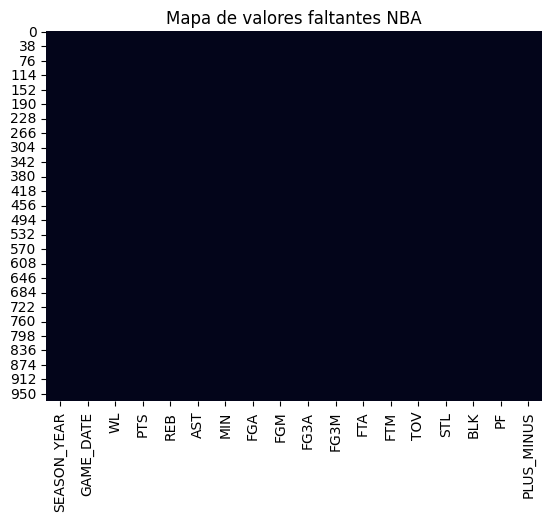

In [23]:
missing_count = df[features].isnull().sum()
missing_percent = (df[features].isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

display(missing_summary)

sns.heatmap(df[features].isnull(), cbar=False)
plt.title("Mapa de valores faltantes NBA")
plt.show()


### **<font color='orange'>Estadísticas descriptivas y de frecuencia</font>**

In [24]:
df[features].drop(columns=['SEASON_YEAR', 'GAME_DATE']).describe().T

,count,mean,std,min,25%,50%,75%,max
PTS,969.0,22.097007,10.074458,0.000000,15.000,22.000000,29.000000,61.000000
REB,969.0,10.943240,4.365042,0.000000,8.000,11.000000,14.000000,27.000000
AST,969.0,7.300310,3.890231,0.000000,4.000,7.000000,10.000000,22.000000
MIN,969.0,31.974701,7.398479,0.658333,27.975,33.713333,36.866667,64.971667
FGA,969.0,15.155831,6.669862,0.000000,10.000,15.000000,20.000000,39.000000
FGM,969.0,8.422085,3.948319,0.000000,6.000,8.000000,11.000000,22.000000
FG3A,969.0,3.216718,2.512055,0.000000,1.000,3.000000,5.000000,14.000000
FG3M,969.0,1.170279,1.216665,0.000000,0.000,1.000000,2.000000,7.000000
FTA,969.0,4.960784,3.703710,0.000000,2.000,4.000000,7.000000,24.000000
FTM,969.0,4.082559,3.193711,0.000000,2.000,4.000000,6.000000,22.000000


In [25]:
df[features].drop(columns=['SEASON_YEAR', 'GAME_DATE']).describe(include=['object']).T

,count,unique,top,freq
WL,969,2,W,581


In [26]:
display(df['WL'].value_counts(dropna=False))

,count
WL,
W,581
L,388


### **<font color='orange'>Partidos perdidos en una temporada concreta</font>**

In [68]:
season = "2021-22"
defeats = df[(df['SEASON_YEAR'] == season) & (df['WL'] == 'L')].shape[0]

print(f"En la temporada {season} hubo {defeats} derrotas")

En la temporada 2021-22 hubo 35 derrotas


### **<font color='pink'>Matriz de correlación</font>**

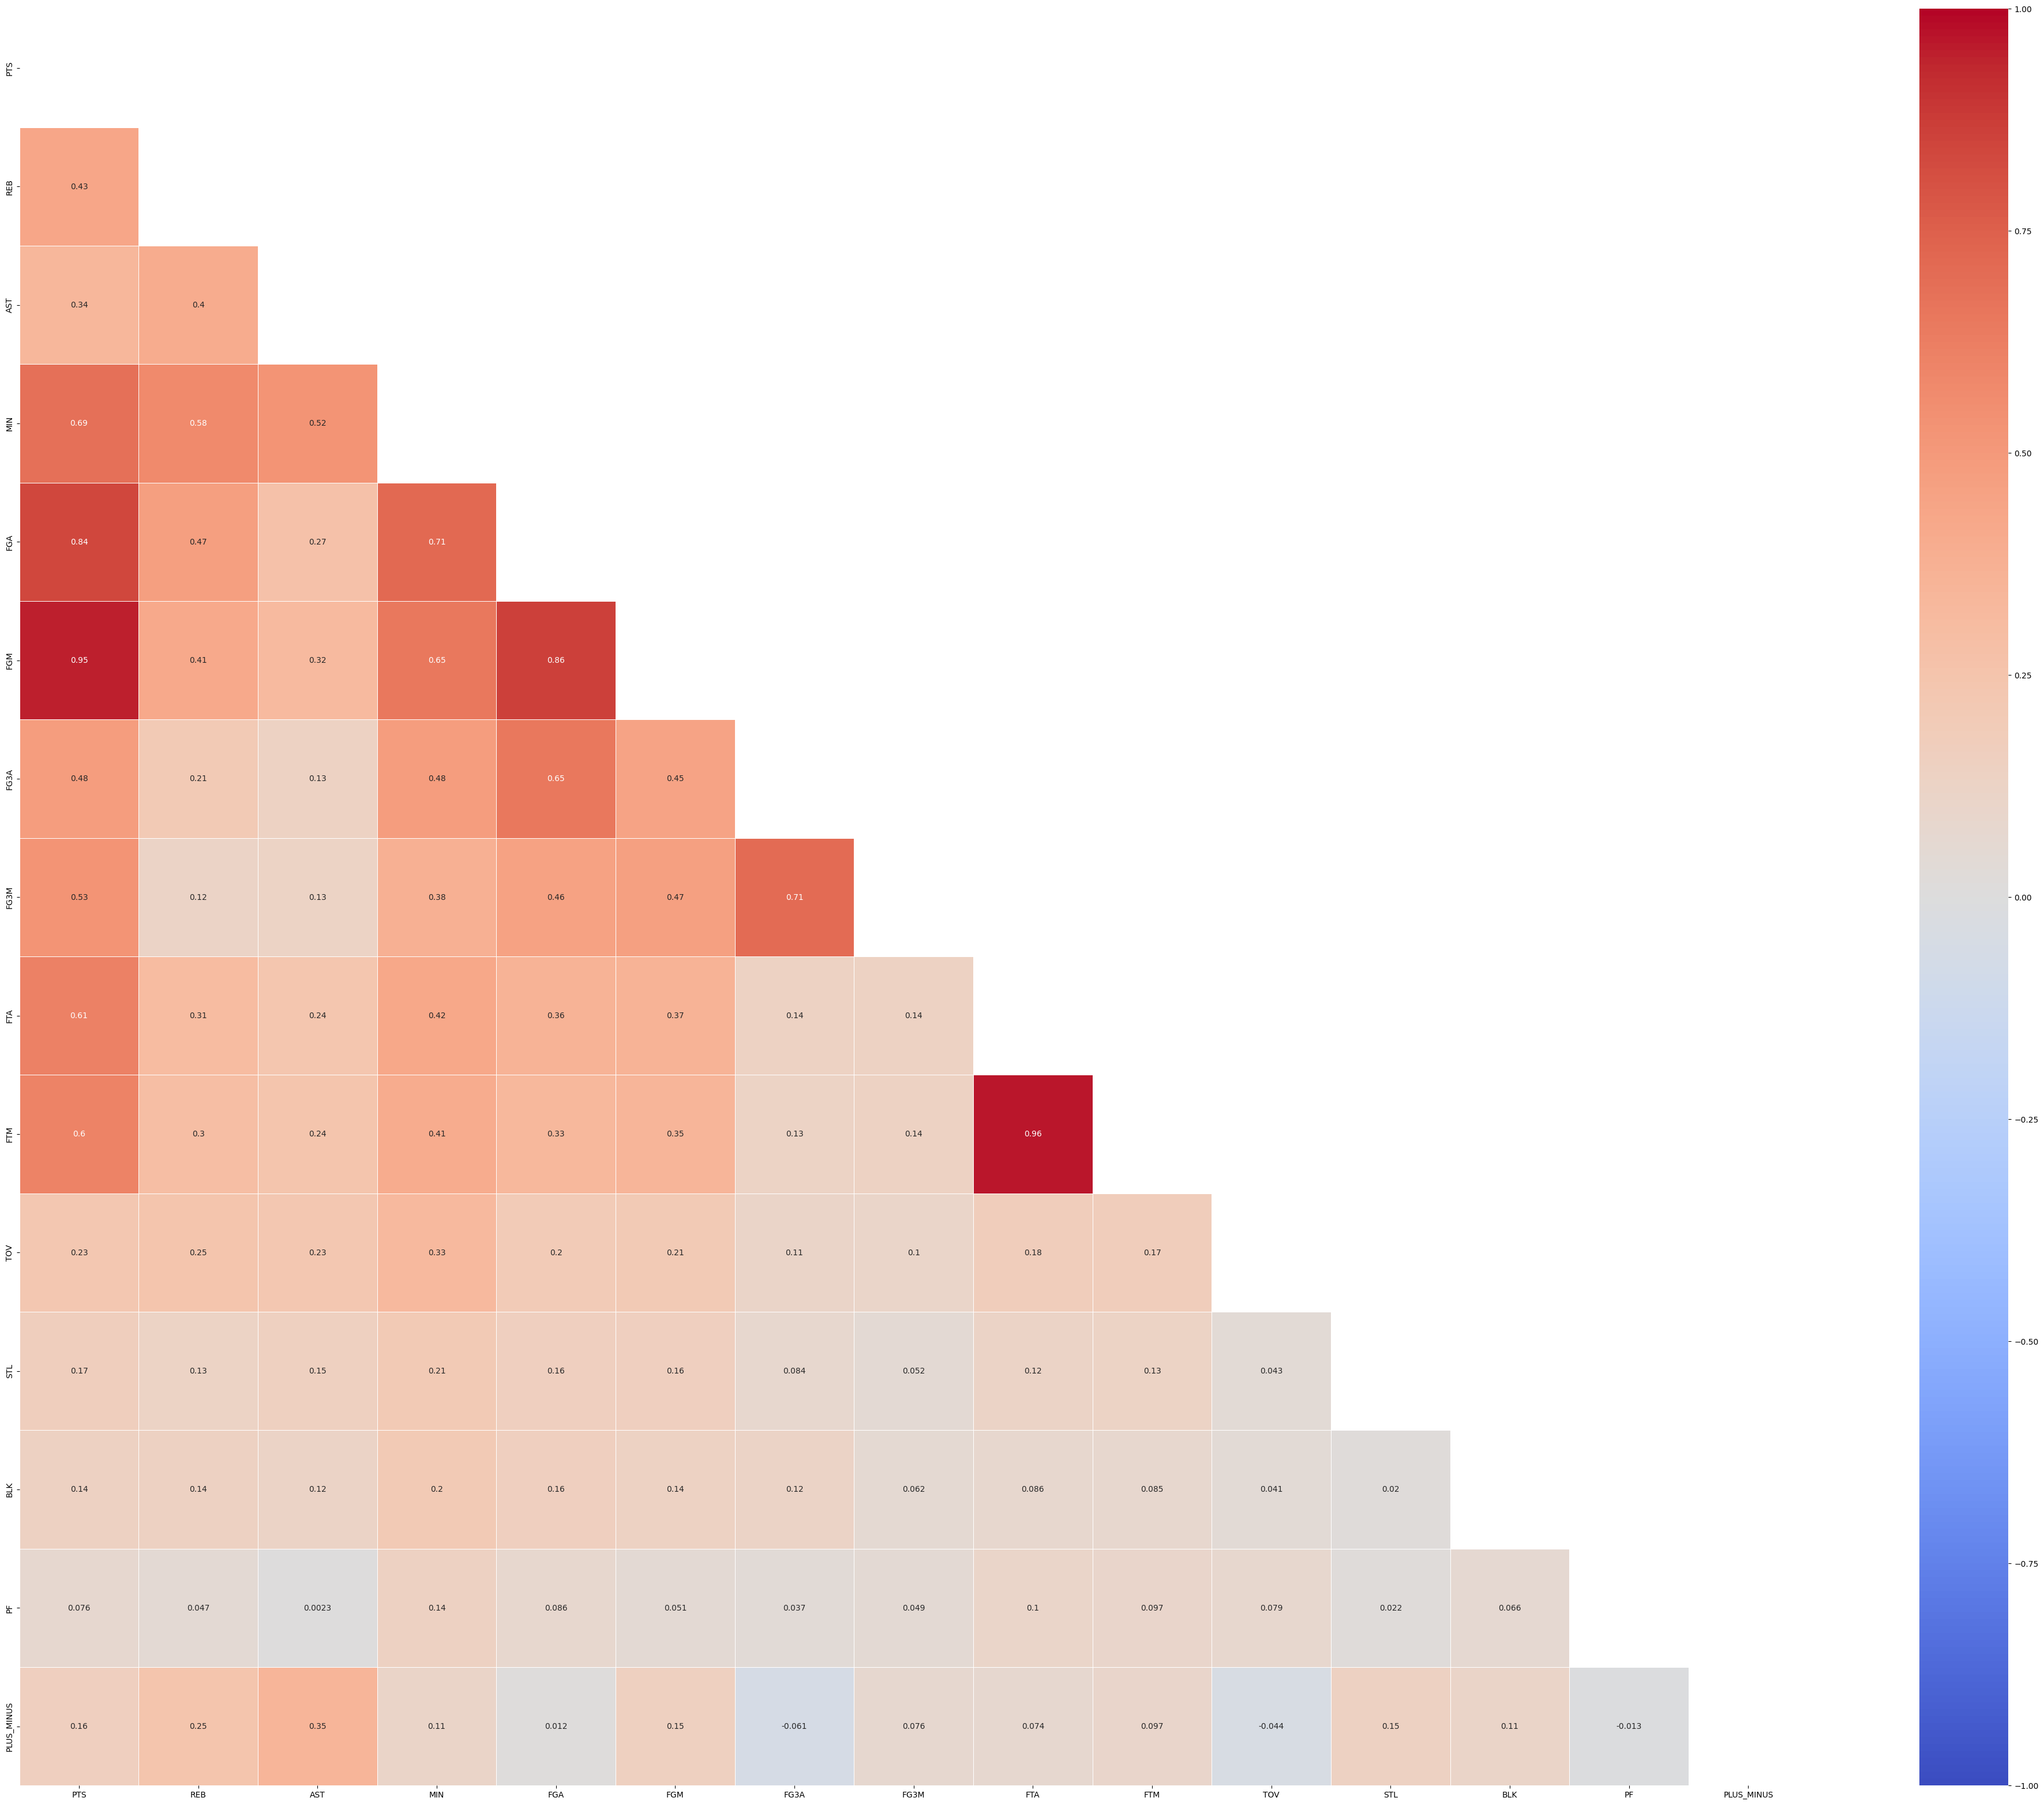

In [28]:
numeric_df = df[features].select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(50, 40))
sns.heatmap(
    corr_matrix,
    mask=mask,       # Aplicar la máscara
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.show()

### **<font color='pink'>Outliers</font>**

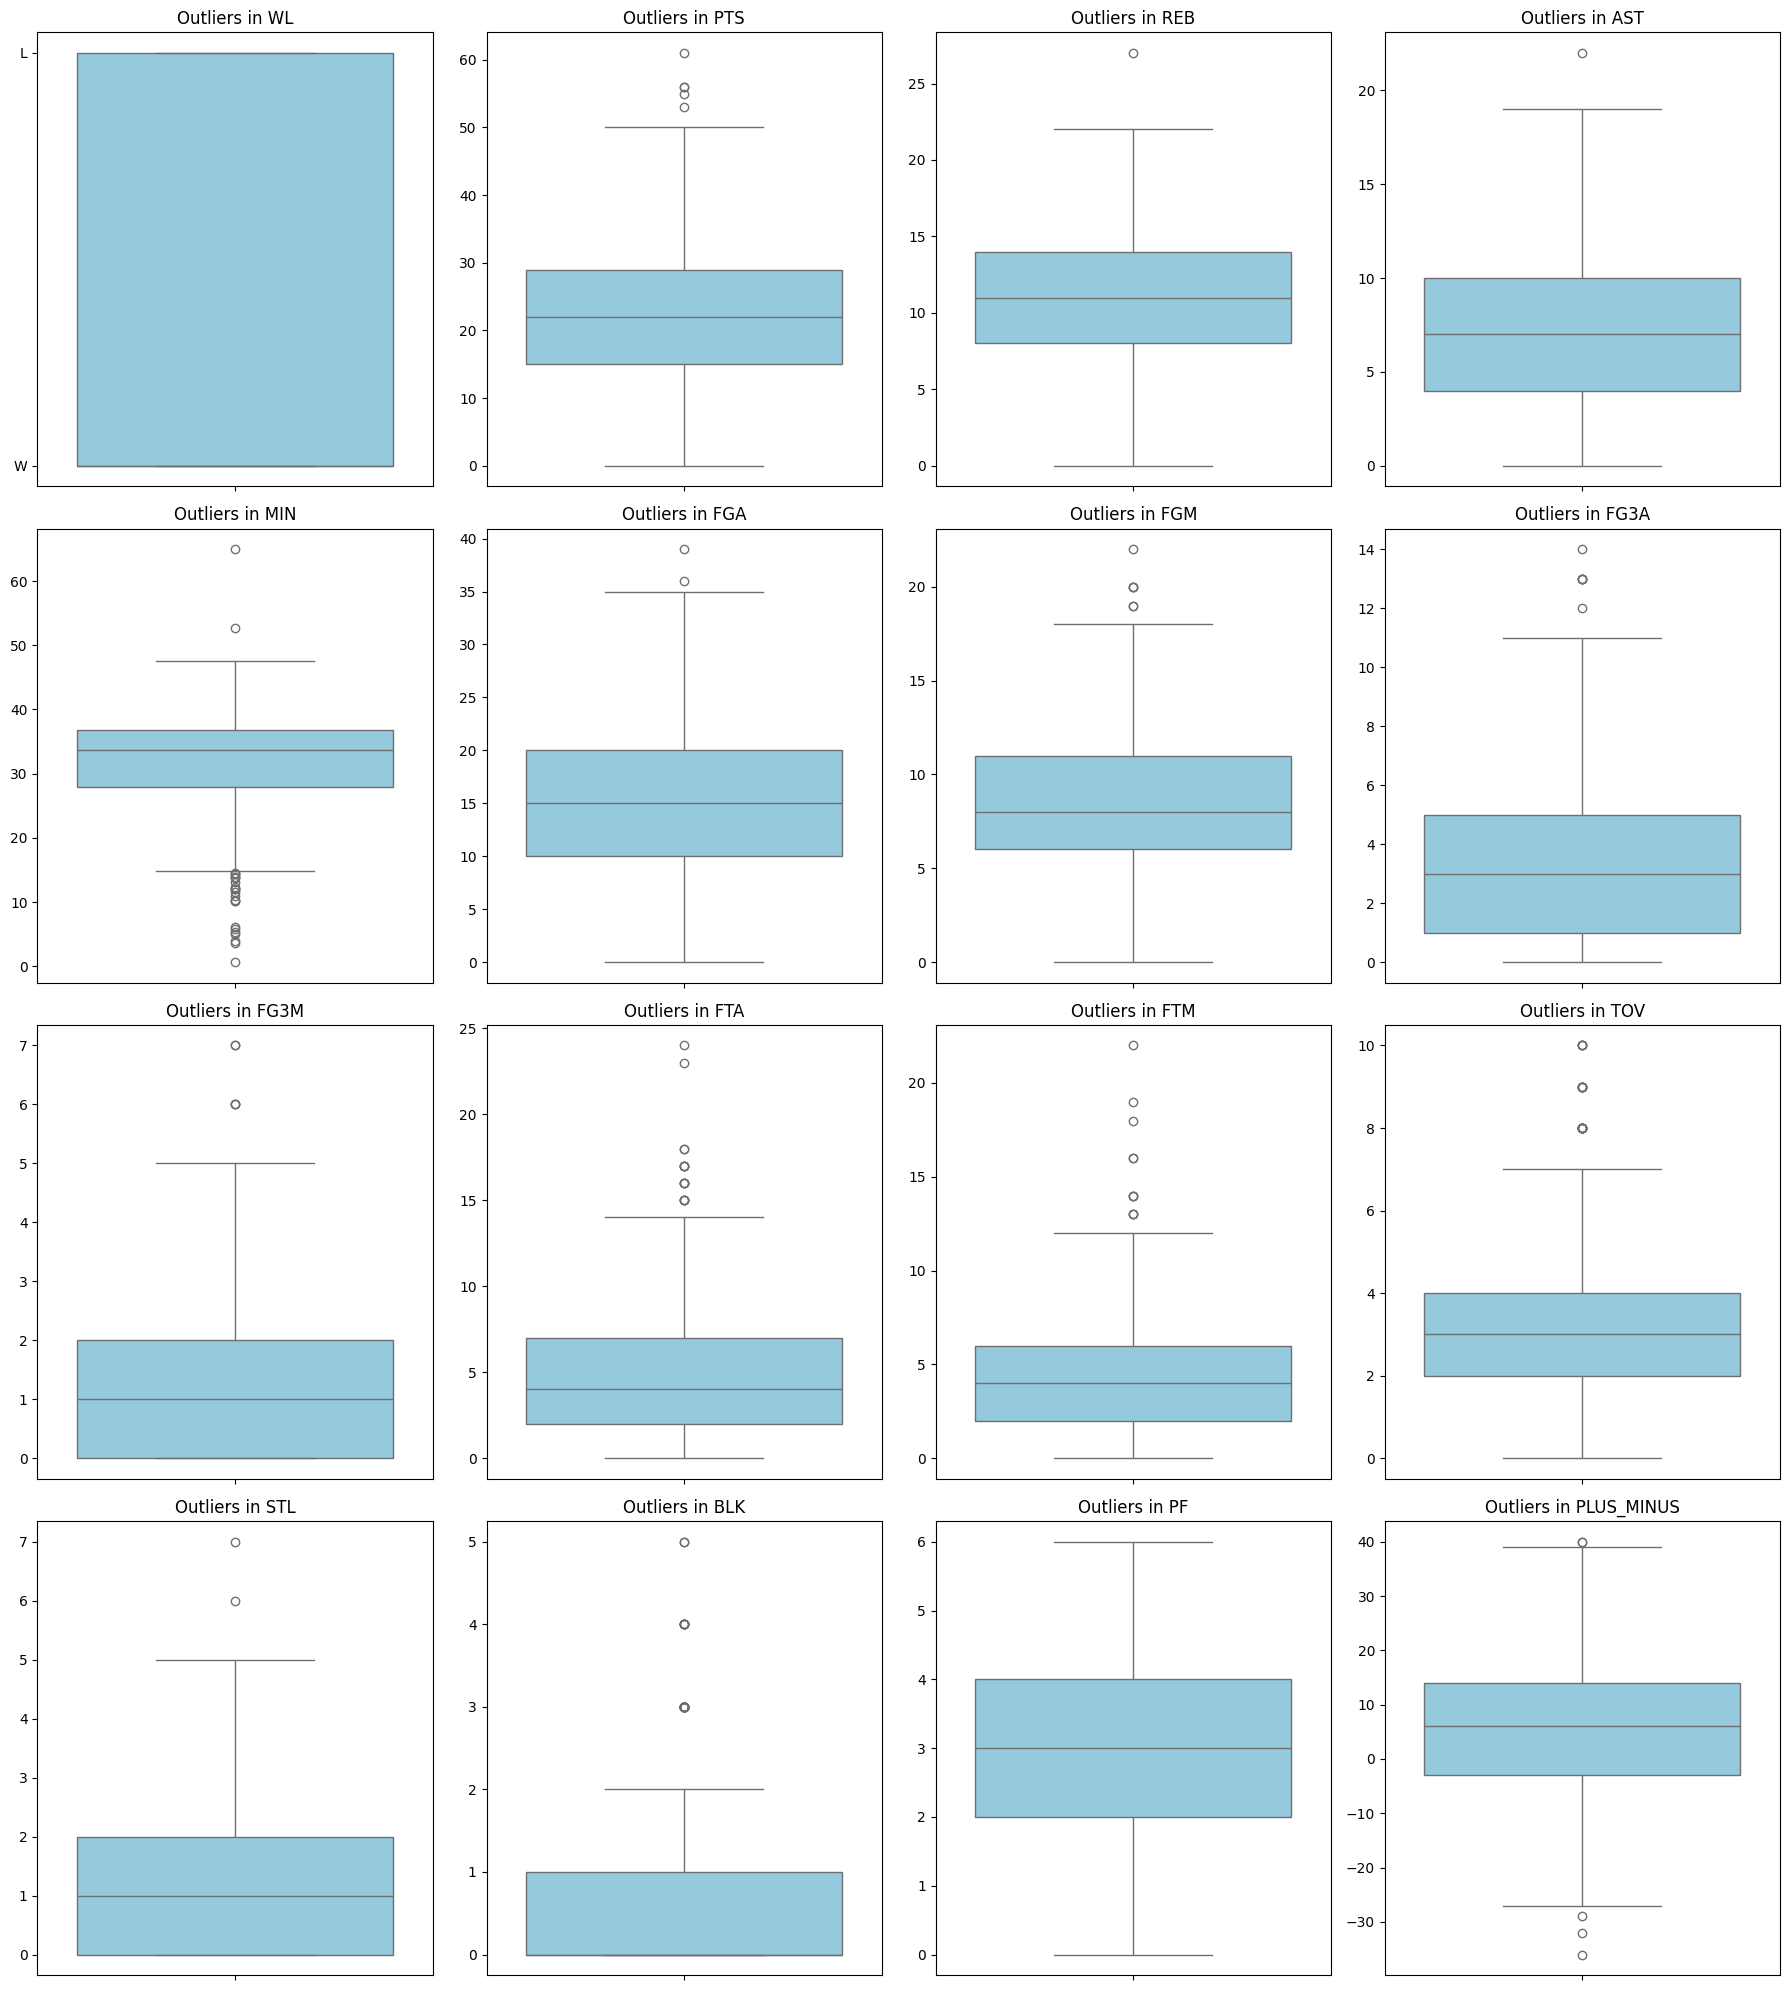

In [40]:
# Configuramos el número de columnas y calculamos las filas necesarias
cols = 4
rows = math.ceil((len(features) - len(cols_exclude)) / cols)
cols_exclude = ['SEASON_YEAR', 'GAME_DATE']

# Creamos la base del cuadro (el lienzo grande)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

# Create a counter for the current axis
axis_idx = 0
for i, col in enumerate(features):

    if col not in cols_exclude:
      sns.boxplot(y=df[col], ax=axes[axis_idx], color='skyblue')
      axes[axis_idx].set_title(f'Outliers in {col}', fontsize=12)
      axes[axis_idx].set_ylabel('')
      axis_idx += 1

# Hide any unused subplots if the last row isn't full
for j in range(axis_idx, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### **<font color='pink'>Victorias y Derrotas (a lo largo de los años)</font>**

WL,L,W
SEASON_YEAR,,
2015-16,0.597701,0.402299
2016-17,0.487500,0.512500
2017-18,0.430380,0.569620
2018-19,0.360000,0.640000
2019-20,0.393939,0.606061
2020-21,0.372093,0.627907
2021-22,0.421687,0.578313
2022-23,0.290323,0.709677
2023-24,0.322917,0.677083


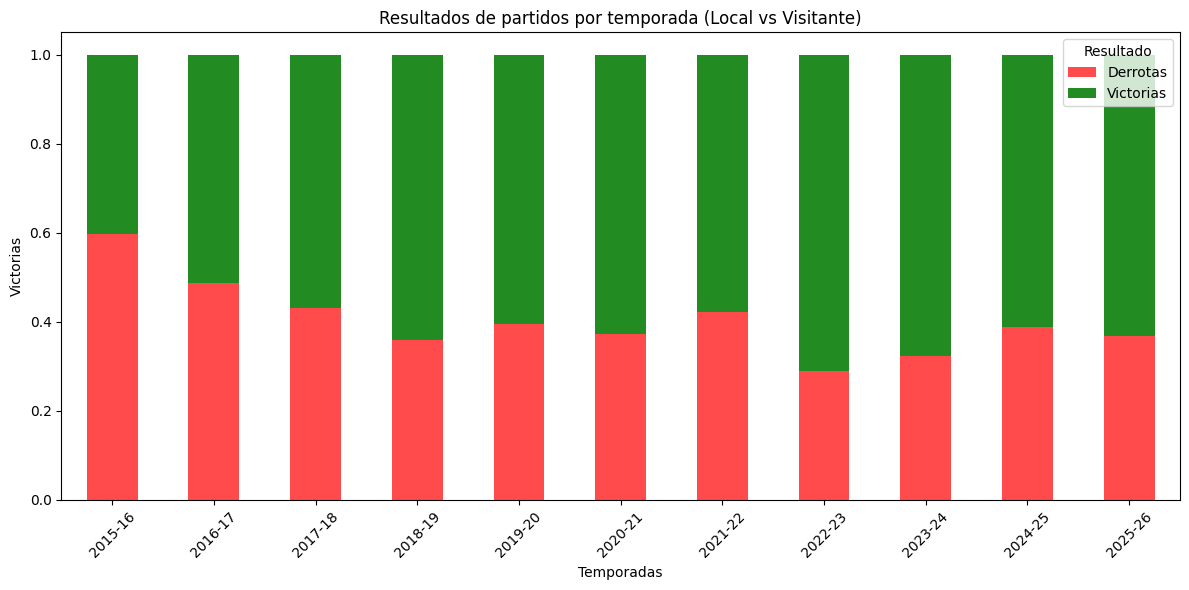

In [48]:
colores = ['#FF4B4B', '#228B22']
result_evolucion = pd.crosstab(index=[df['SEASON_YEAR']],
                               columns=df['WL'],
                               normalize='index')

display(result_evolucion)

ax = result_evolucion.plot(kind='bar',
                           figsize=(12, 6),
                           stacked=True,
                           color=colores)

plt.title('Resultados de partidos por temporada (Local vs Visitante)')
plt.xlabel('Temporadas')
plt.ylabel('Victorias')
plt.legend(title='Resultado', labels=['Derrotas', 'Victorias'], loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **<font color='pink'>PTS, AST, REB (a lo largo de los años)</font>**

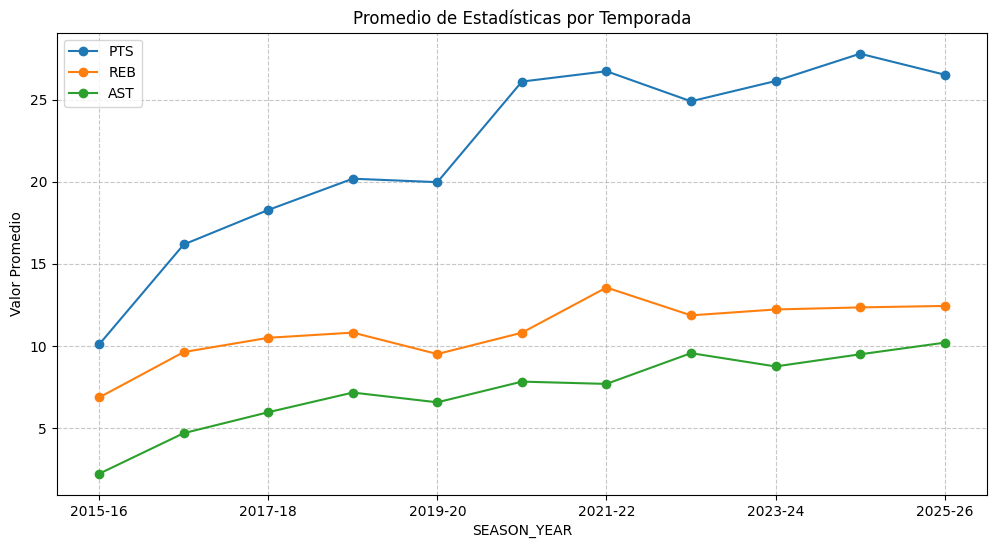

In [65]:
# Agrupamos por año y sacamos la media
evolucion_media = df.groupby('SEASON_YEAR')[['PTS', 'REB', 'AST']].mean()

evolucion_media.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Promedio de Estadísticas por Temporada')
plt.ylabel('Valor Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **<font color='pink'>Histogramas</font>**

#### PTS

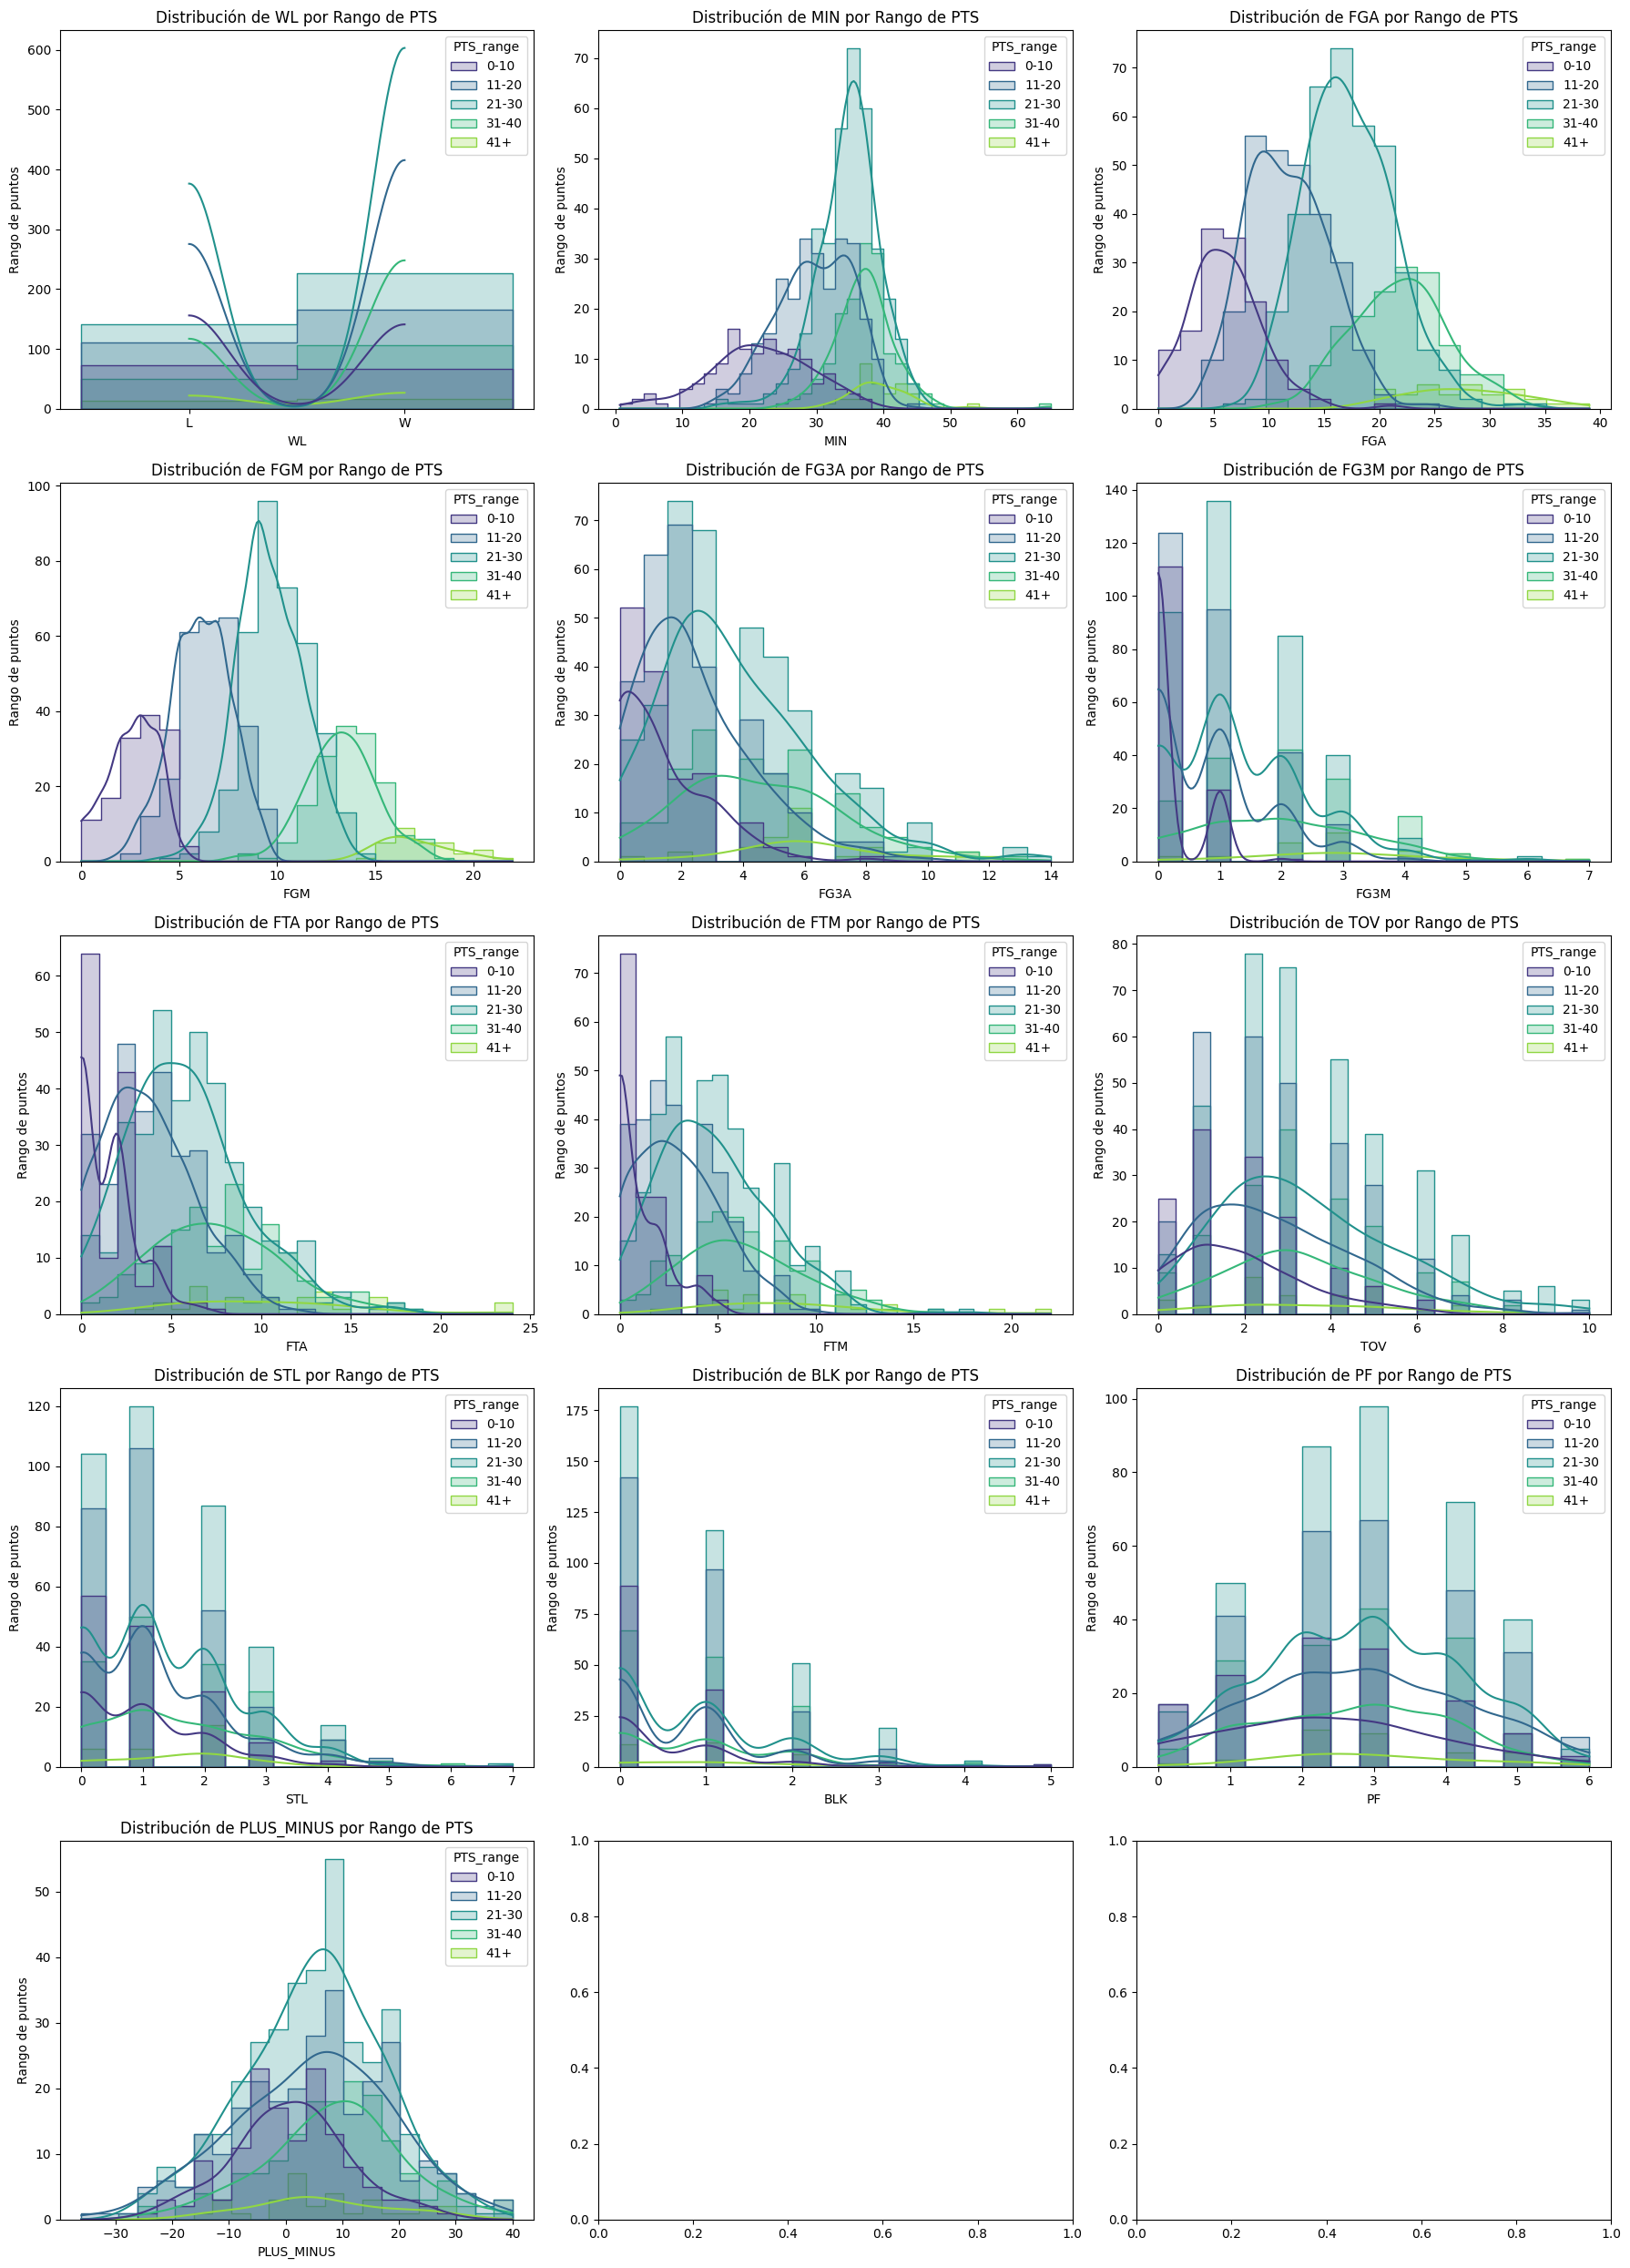

In [52]:
df_histogram = df.copy()


bins = [0, 10, 20, 30, 40, 150]
labels = ['0-10', '11-20', '21-30', '31-40', '150+']

# Creamos la nueva columna
df_histogram['PTS_range'] = pd.cut(df_histogram['PTS'],
                                   bins=bins,
                                   labels=labels,
                                   include_lowest=True)

colums_analyze = [
    # Resultado del partido
    'WL',

    # Básicos
    'MIN',        # Minutos de juego .

    # Tiros (volumen + eficiencia)
    'FGA',        # Tiros de campo intentados
    'FGM',        # Tiros de campo convertidos
    'FG3A',       # Tiros de 3 intentados
    'FG3M',       # Tiros de 3 convertidos
    'FTA',        # Tiros libres intentados
    'FTM',        # Tiros libres convertidos

    # Otras estadísticas
    'TOV',        # Pérdidas de balón (Turnovers).
    'STL',        # Robos de balón (Steals).
    'BLK',        # Tapones realizados (Blocks).
    'PF',         # Faltas personales (Personal Fouls).
    'PLUS_MINUS', # Diferencia de puntos del equipo cuando el jugador está en cancha.
]

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df_histogram,
                 x=col,
                 hue='PTS_range',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Rango de PTS', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Rango de puntos')

plt.tight_layout()
plt.show()

#### AST

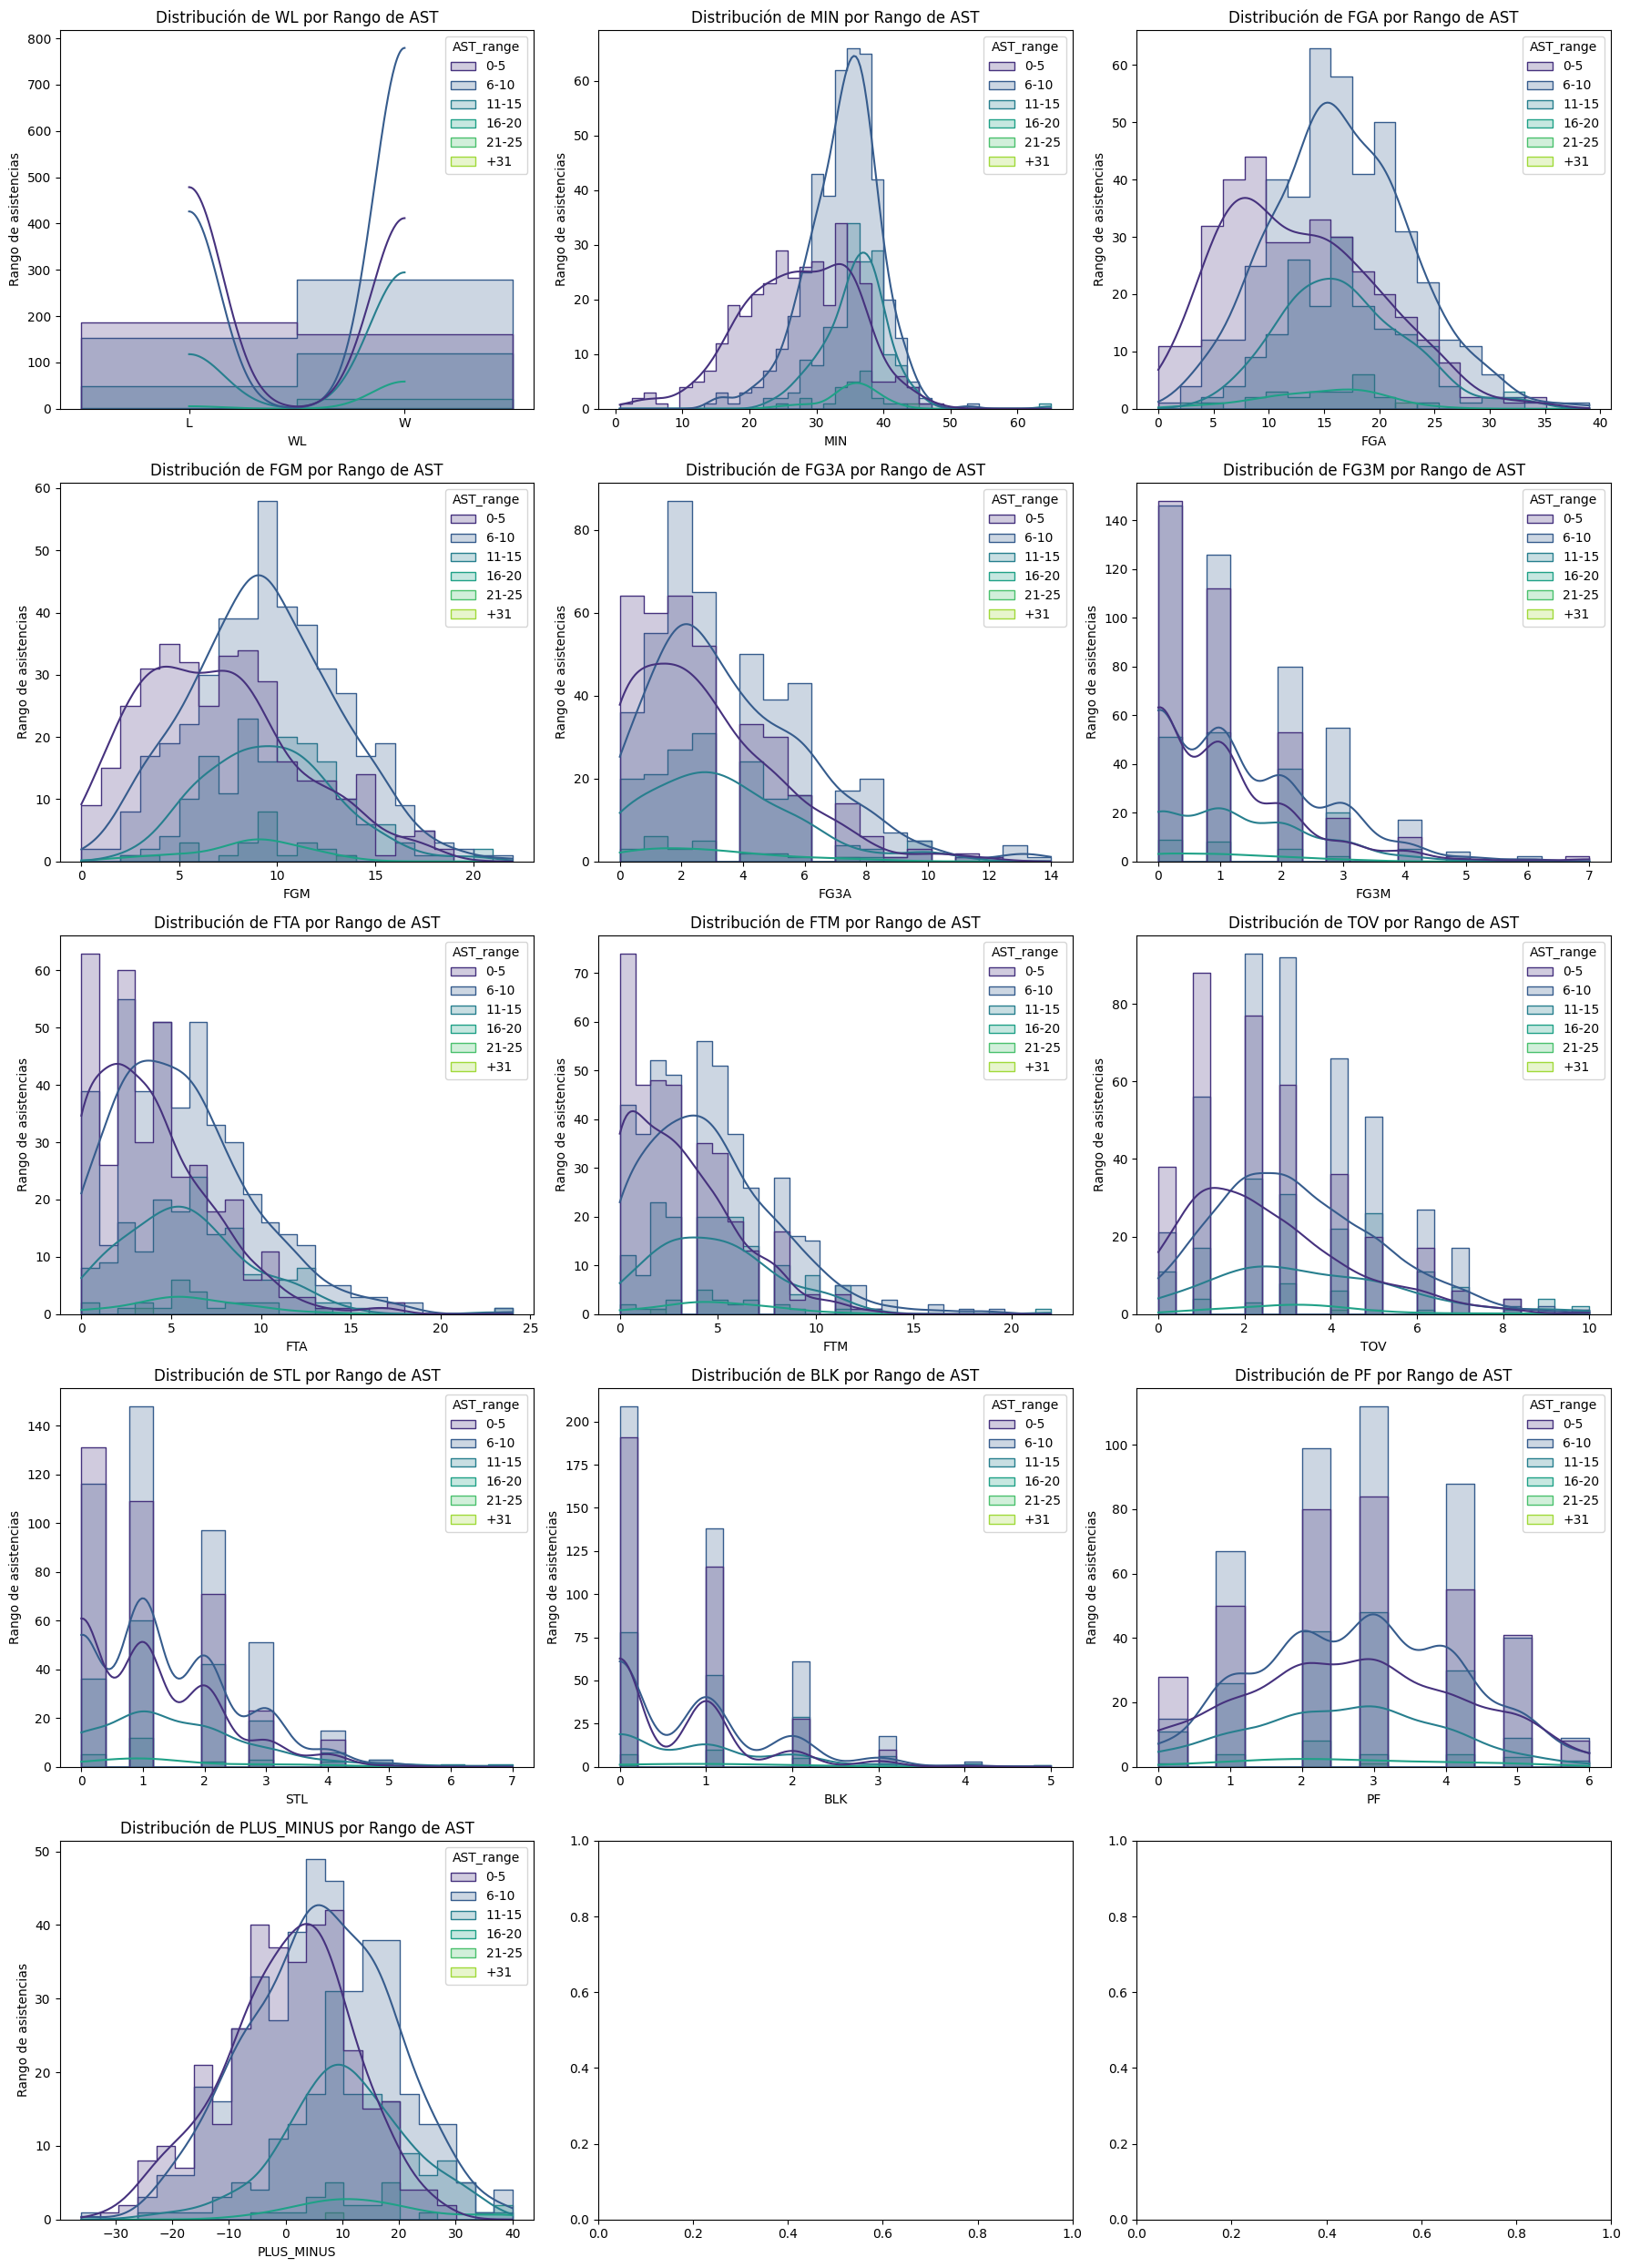

In [56]:
df_histogram = df.copy()


bins = [0, 5, 10, 15, 20, 25, 30]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '+31']

# Creamos la nueva columna
df_histogram['AST_range'] = pd.cut(df_histogram['AST'],
                                   bins=bins,
                                   labels=labels,
                                   include_lowest=True)

colums_analyze = [
    # Resultado del partido
    'WL',

    # Básicos
    'MIN',        # Minutos de juego .

    # Tiros (volumen + eficiencia)
    'FGA',        # Tiros de campo intentados
    'FGM',        # Tiros de campo convertidos
    'FG3A',       # Tiros de 3 intentados
    'FG3M',       # Tiros de 3 convertidos
    'FTA',        # Tiros libres intentados
    'FTM',        # Tiros libres convertidos

    # Otras estadísticas
    'TOV',        # Pérdidas de balón (Turnovers).
    'STL',        # Robos de balón (Steals).
    'BLK',        # Tapones realizados (Blocks).
    'PF',         # Faltas personales (Personal Fouls).
    'PLUS_MINUS', # Diferencia de puntos del equipo cuando el jugador está en cancha.
]

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df_histogram,
                 x=col,
                 hue='AST_range',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Rango de AST', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Rango de asistencias')

plt.tight_layout()
plt.show()

#### REB

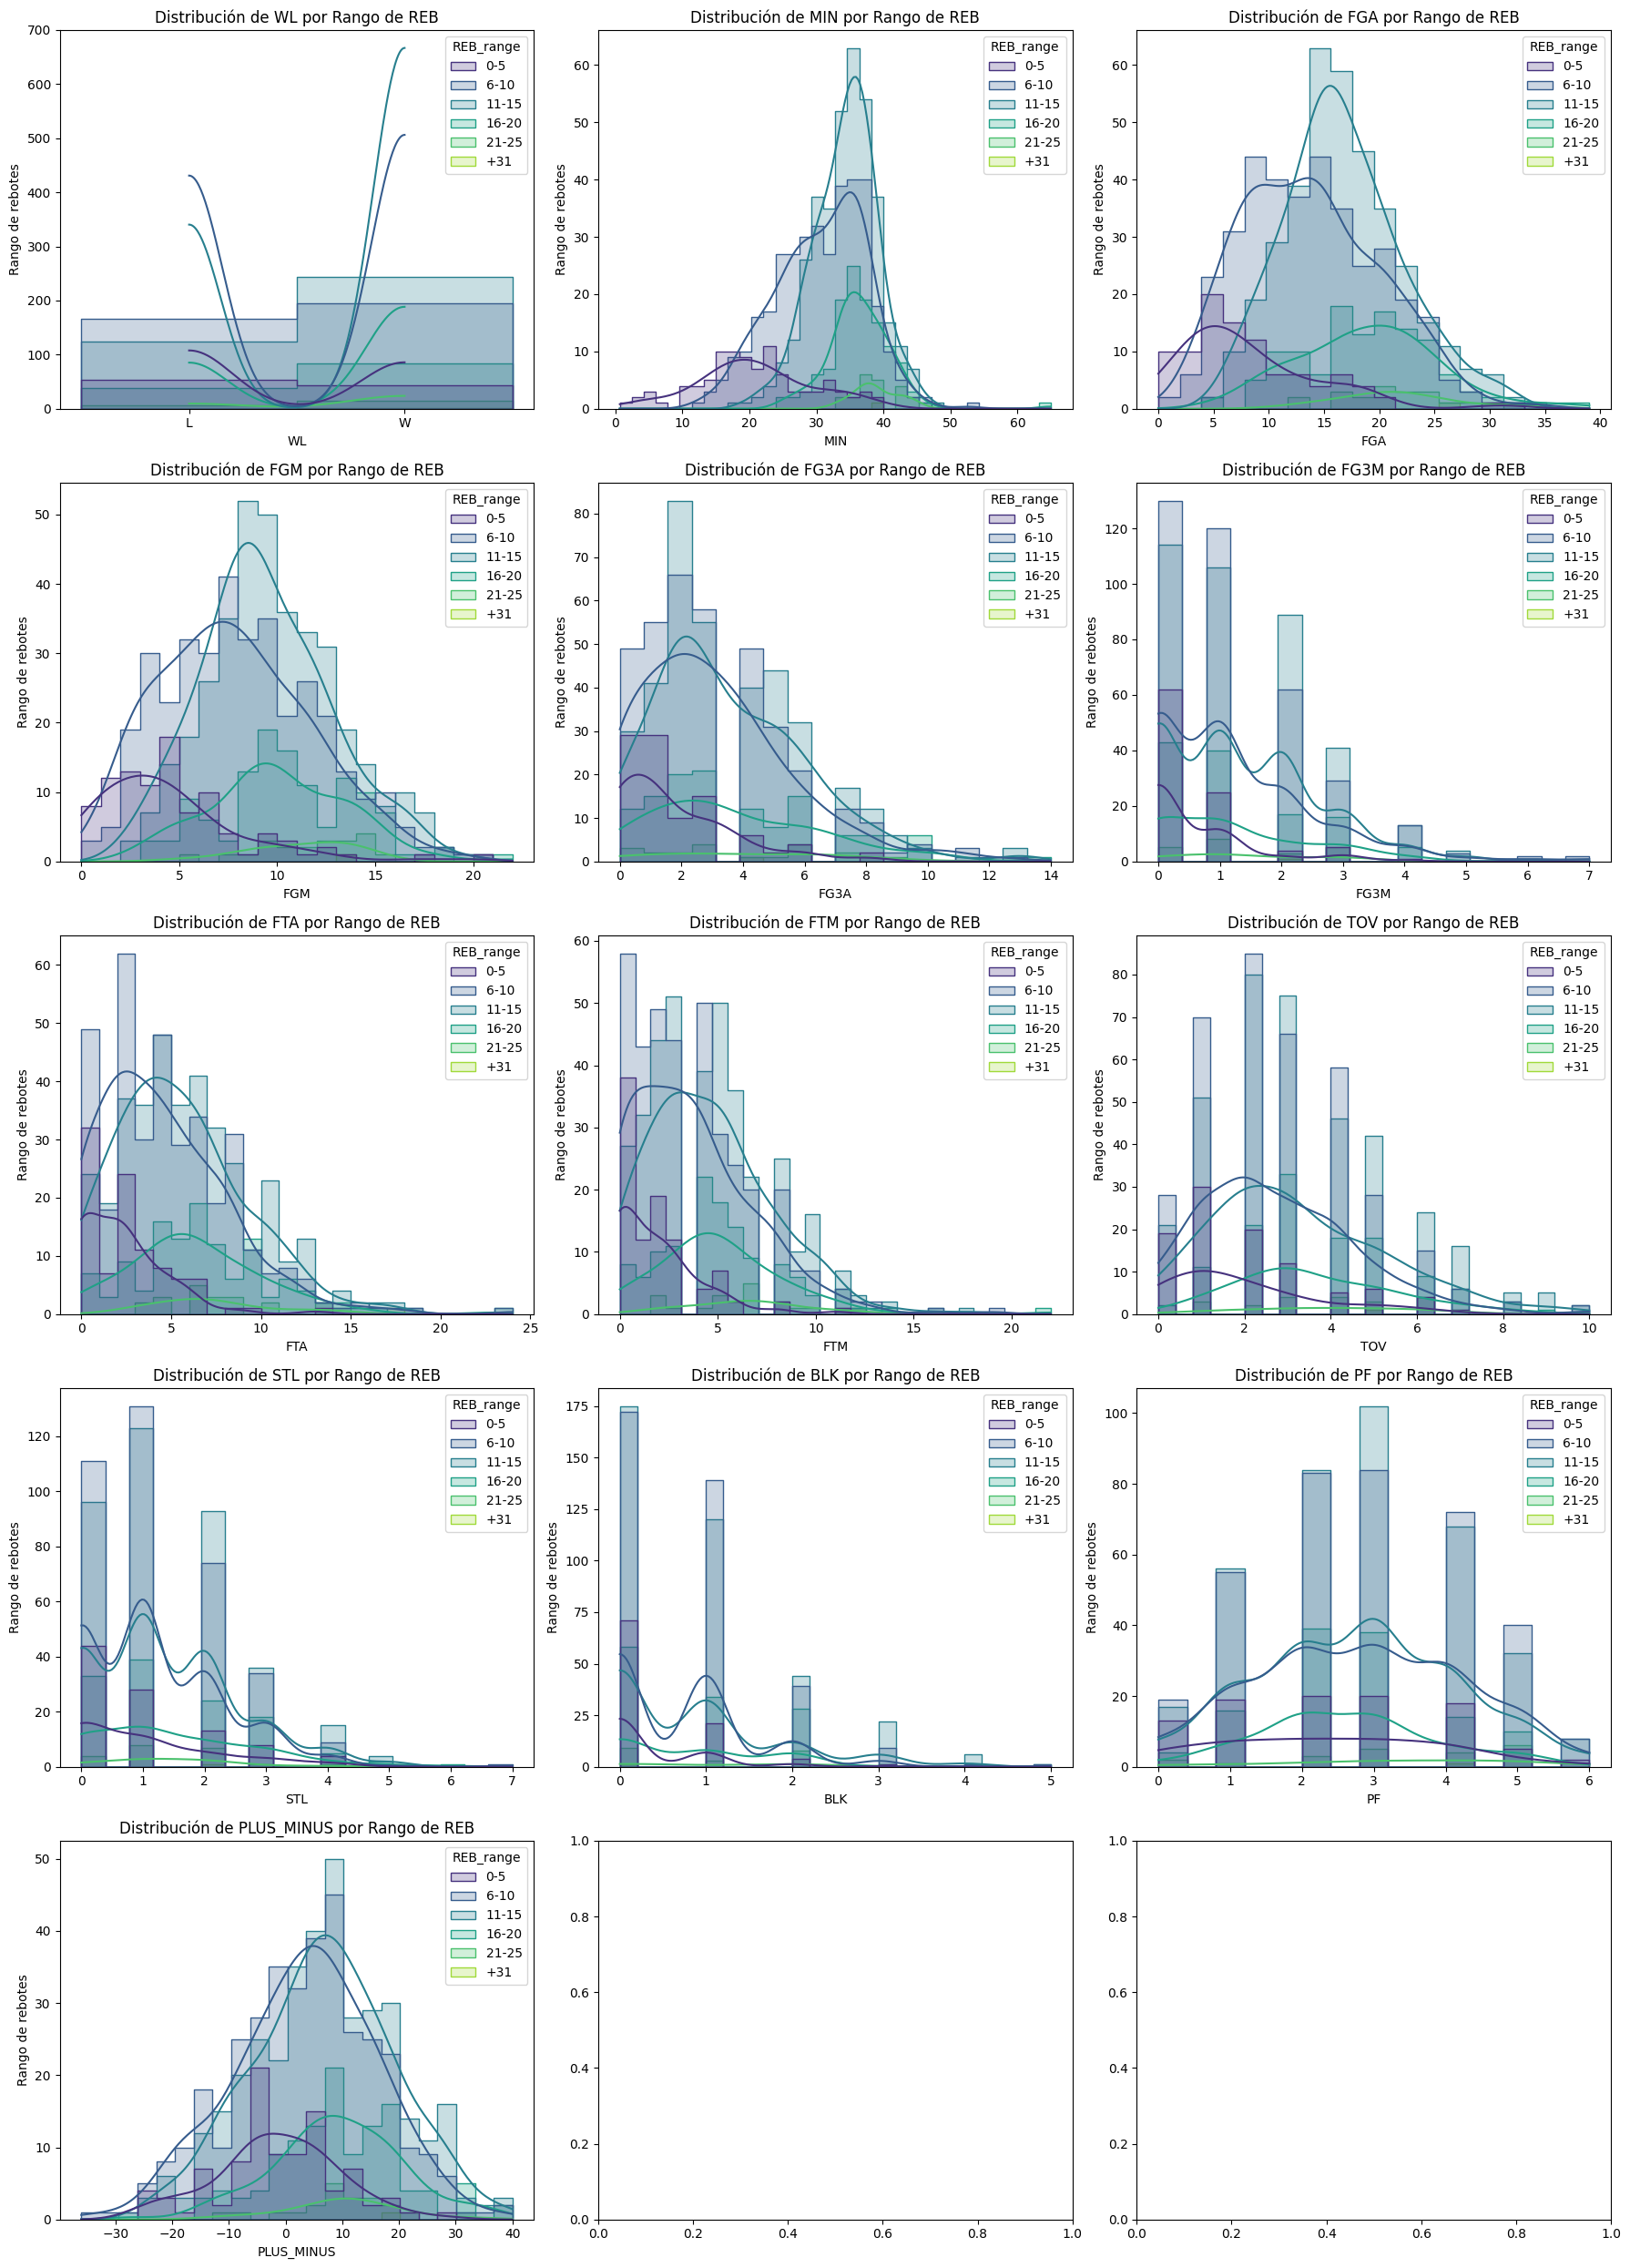

In [57]:
df_histogram = df.copy()


bins = [0, 5, 10, 15, 20, 25, 30]
labels = ['0-5', '6-10', '11-15', '16-20', '21-25', '+31']

# Creamos la nueva columna
df_histogram['REB_range'] = pd.cut(df_histogram['REB'],
                                   bins=bins,
                                   labels=labels,
                                   include_lowest=True)

colums_analyze = [
    # Resultado del partido
    'WL',

    # Básicos
    'MIN',        # Minutos de juego .

    # Tiros (volumen + eficiencia)
    'FGA',        # Tiros de campo intentados
    'FGM',        # Tiros de campo convertidos
    'FG3A',       # Tiros de 3 intentados
    'FG3M',       # Tiros de 3 convertidos
    'FTA',        # Tiros libres intentados
    'FTM',        # Tiros libres convertidos

    # Otras estadísticas
    'TOV',        # Pérdidas de balón (Turnovers).
    'STL',        # Robos de balón (Steals).
    'BLK',        # Tapones realizados (Blocks).
    'PF',         # Faltas personales (Personal Fouls).
    'PLUS_MINUS', # Diferencia de puntos del equipo cuando el jugador está en cancha.
]

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df_histogram,
                 x=col,
                 hue='REB_range',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Rango de REB', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Rango de rebotes')

plt.tight_layout()
plt.show()

### **<font color='pink'>Valores nulos</font>**

<Axes: >

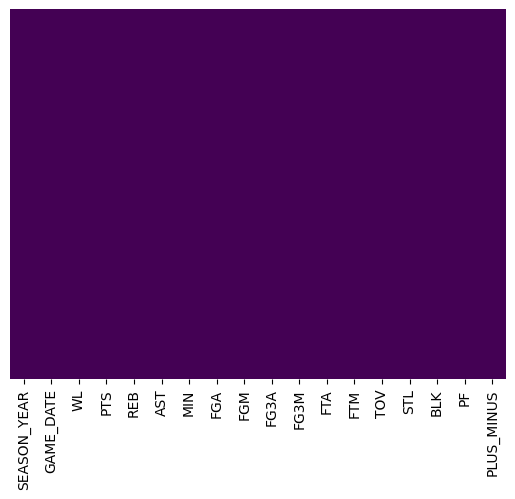

In [59]:
sns.heatmap(df[features].isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')